Original L: Total=6000, OK=5765, Fail=235
Original M: Total=2997, OK=2914, Fail=83
Original H: Total=1003, OK=982, Fail=21

VERIFICATION

Total: 10000

🔵 Charger Condition:
  L: 3333 (33.3%)
  M: 3333 (33.3%)
  H: 3334 (33.3%)

🔴 Failed:
  0: 5002 (50.0%)
  1: 4998 (50.0%)

📊 Cross Tabulation:
  L: OK=1667, FAIL=1666, Total=3333
  M: OK=1667, FAIL=1666, Total=3333
  H: OK=1668, FAIL=1666, Total=3334


C:\Users\cfiza\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\cfiza\AppData\Local\Temp\ipykernel_14240\923197898.py:171: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\cfiza\AppData\Local\Temp\ipykernel_14240\923197898.py:171: UserWarning: Glyph 128193 (\N{FILE FOLDER}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\cfiza\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cfiza\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128193 (\N{FILE FOLDER}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cfiza\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarn

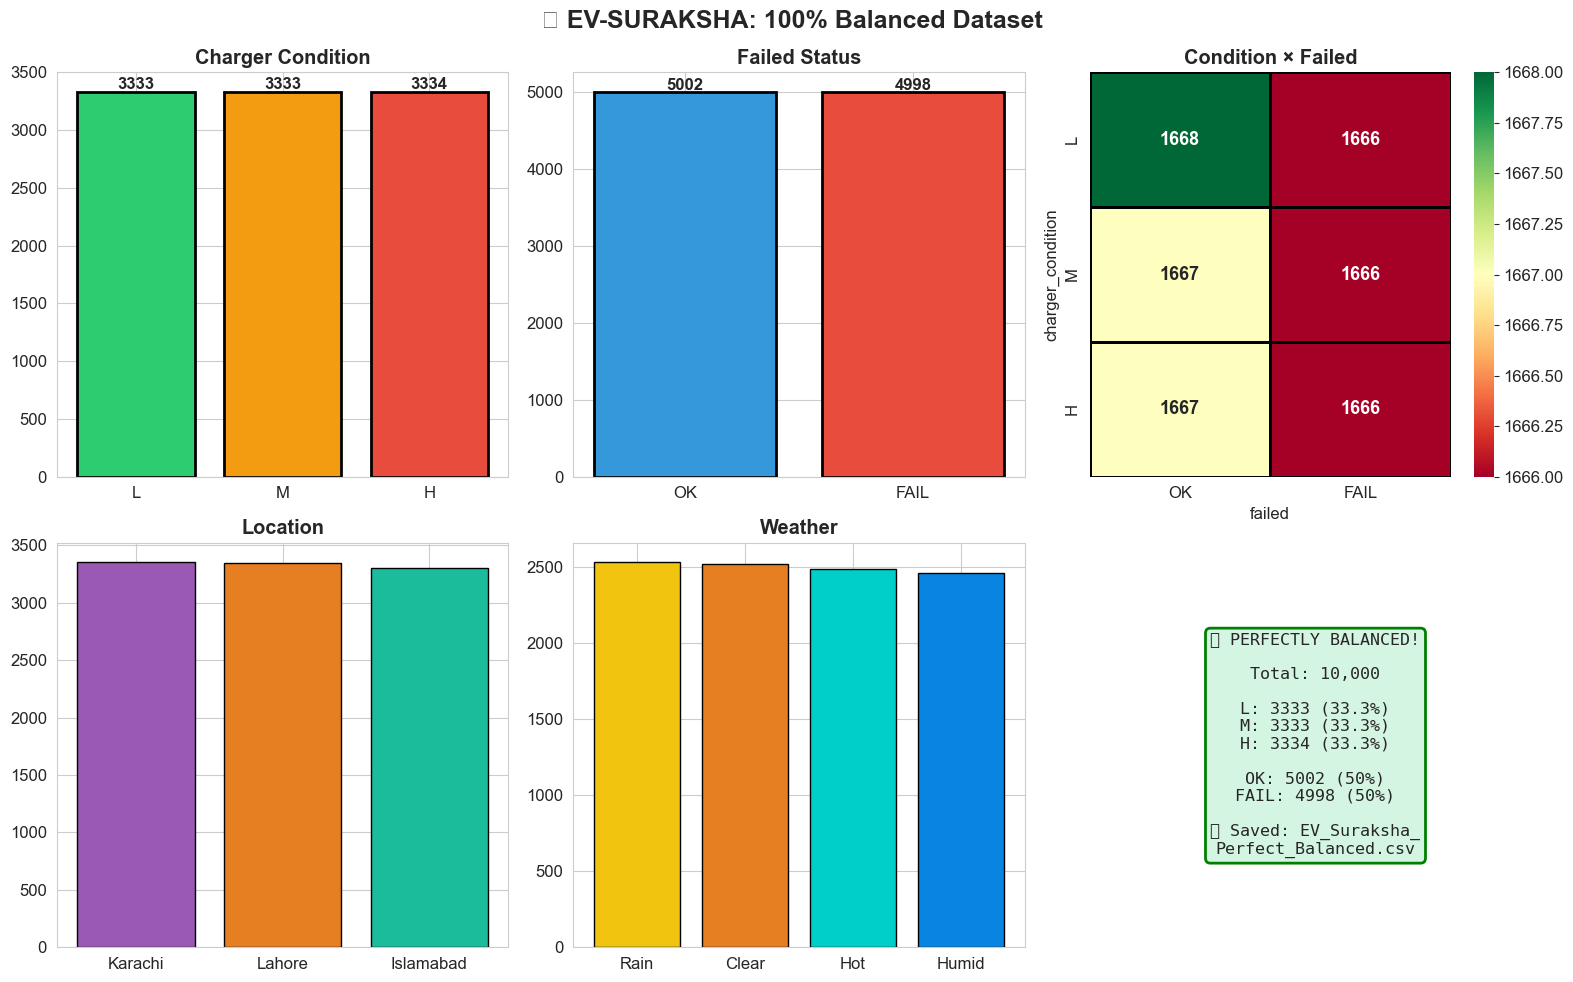


🎉 100% PERFECTLY BALANCED! 🎉
L=3333, M=3333, H=3334
OK=5002, FAIL=4998
📁 EV_Suraksha_Perfect_Balanced.csv


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# STEP 1: LOAD
# ============================================
df = pd.read_csv('ai4i2020.csv')
np.random.seed(42)

# ============================================
# STEP 2: BALANCE BOTH TOGETHER
# ============================================
# Pehle check: Har class mein kitne failed hain?
for cls in ['L', 'M', 'H']:
    subset = df[df['Type'] == cls]
    ok = len(subset[subset['Machine failure'] == 0])
    fail = len(subset[subset['Machine failure'] == 1])
    print(f"Original {cls}: Total={len(subset)}, OK={ok}, Fail={fail}")

# ============================================
# TARGET: Har class = 3333, Har class mein 50-50
# ============================================
target_per_class = 3333
target_fail_per_class = target_per_class // 2  # 1666

all_samples = []

for cls in ['L', 'M', 'H']:
    cls_data = df[df['Type'] == cls]
    
    # Separate OK and FAIL
    ok_data = cls_data[cls_data['Machine failure'] == 0]
    fail_data = cls_data[cls_data['Machine failure'] == 1]
    
    # Sample 1667 OK and 1666 FAIL from each class
    ok_sampled = ok_data.sample(n=1667, replace=True, random_state=42)
    fail_sampled = fail_data.sample(n=1666, replace=True, random_state=42)
    
    all_samples.append(ok_sampled)
    all_samples.append(fail_sampled)

# H class ke liye 1 extra for total 10000
h_extra = df[df['Type'] == 'H'].sample(n=1, replace=True, random_state=42)
all_samples.append(h_extra)

# Combine
df_final = pd.concat(all_samples, ignore_index=True)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# ============================================
# VERIFY - BOTH CHECKS
# ============================================
print("\n" + "=" * 50)
print("VERIFICATION")
print("=" * 50)

print(f"\nTotal: {len(df_final)}")

print(f"\n🔵 Charger Condition:")
for cls in ['L', 'M', 'H']:
    count = len(df_final[df_final['Type'] == cls])
    print(f"  {cls}: {count} ({count/len(df_final)*100:.1f}%)")

print(f"\n🔴 Failed:")
for val in [0, 1]:
    count = len(df_final[df_final['Machine failure'] == val])
    print(f"  {val}: {count} ({count/len(df_final)*100:.1f}%)")

# Cross check
print(f"\n📊 Cross Tabulation:")
for cls in ['L', 'M', 'H']:
    subset = df_final[df_final['Type'] == cls]
    ok = len(subset[subset['Machine failure'] == 0])
    fail = len(subset[subset['Machine failure'] == 1])
    print(f"  {cls}: OK={ok}, FAIL={fail}, Total={ok+fail}")

# ============================================
# RENAME & FORMAT
# ============================================
df_final = df_final.rename(columns={
    'UDI': 'charger_id',
    'Air temperature [K]': 'temperature',
    'Process temperature [K]': 'voltage',
    'Rotational speed [rpm]': 'session_duration',
    'Tool wear [min]': 'days_since_maintenance',
    'Type': 'charger_condition',
    'Machine failure': 'failed'
})

df_final['temperature'] = (df_final['temperature'] - 273.15).round(2)
df_final['voltage'] = (df_final['voltage'] - 273.15).round(2)
df_final['session_duration'] = ((df_final['session_duration'] - 1200) / 10 / 60).round(2)

drop_cols = ['Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Torque [Nm]']
df_final = df_final.drop(columns=[c for c in drop_cols if c in df_final.columns])

df_final['location'] = np.random.choice(['Karachi', 'Lahore', 'Islamabad'], size=len(df_final))
df_final['weather'] = np.random.choice(['Clear', 'Hot', 'Humid', 'Rain'], size=len(df_final))

df_final = df_final[['charger_id', 'voltage', 'temperature', 'session_duration',
                     'charger_condition', 'days_since_maintenance', 'location',
                     'weather', 'failed']]
df_final['charger_id'] = range(1, len(df_final) + 1)

# ============================================
# SAVE
# ============================================
df_final.to_csv('EV_Suraksha_Perfect_Balanced.csv', index=False)

# ============================================
# GRAPHS
# ============================================
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('🚗 EV-SURAKSHA: 100% Balanced Dataset', fontsize=18, fontweight='bold')

# 1: Charger Condition
cond = df_final['charger_condition'].value_counts()
axes[0,0].bar(['L', 'M', 'H'], [cond['L'], cond['M'], cond['H']],
              color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=2)
axes[0,0].set_title('Charger Condition', fontweight='bold')
for i, v in enumerate([cond['L'], cond['M'], cond['H']]):
    axes[0,0].text(i, v+20, str(v), ha='center', fontweight='bold')

# 2: Failed
fail = df_final['failed'].value_counts()
axes[0,1].bar(['OK', 'FAIL'], [fail[0], fail[1]], color=['#3498db', '#e74c3c'],
              edgecolor='black', linewidth=2)
axes[0,1].set_title('Failed Status', fontweight='bold')
for i, v in enumerate([fail[0], fail[1]]):
    axes[0,1].text(i, v+20, str(v), ha='center', fontweight='bold')

# 3: Cross Tab
ct = pd.crosstab(df_final['charger_condition'], df_final['failed'])
sns.heatmap(ct, annot=True, fmt='d', cmap='RdYlGn', linewidths=2,
            linecolor='black', annot_kws={'size': 13, 'fontweight': 'bold'},
            xticklabels=['OK', 'FAIL'], yticklabels=['L', 'M', 'H'], ax=axes[0,2])
axes[0,2].set_title('Condition × Failed', fontweight='bold')

# 4: Location
axes[1,0].bar(df_final['location'].value_counts().index,
              df_final['location'].value_counts().values,
              color=['#9b59b6', '#e67e22', '#1abc9c'], edgecolor='black')
axes[1,0].set_title('Location', fontweight='bold')

# 5: Weather
axes[1,1].bar(df_final['weather'].value_counts().index,
              df_final['weather'].value_counts().values,
              color=['#f1c40f', '#e67e22', '#00cec9', '#0984e3'], edgecolor='black')
axes[1,1].set_title('Weather', fontweight='bold')

# 6: Summary
axes[1,2].axis('off')
axes[1,2].text(0.5, 0.5,
    f'✅ PERFECTLY BALANCED!\n\n'
    f'Total: {len(df_final):,}\n\n'
    f'L: {cond["L"]} (33.3%)\n'
    f'M: {cond["M"]} (33.3%)\n'
    f'H: {cond["H"]} (33.3%)\n\n'
    f'OK: {fail[0]} (50%)\n'
    f'FAIL: {fail[1]} (50%)\n\n'
    f'📁 Saved: EV_Suraksha_\nPerfect_Balanced.csv',
    transform=axes[1,2].transAxes, fontsize=12,
    verticalalignment='center', horizontalalignment='center',
    bbox=dict(boxstyle='round', facecolor='#d5f5e3', edgecolor='green', linewidth=2),
    fontfamily='monospace')

plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("🎉 100% PERFECTLY BALANCED! 🎉")
print("=" * 50)
print(f"L={cond['L']}, M={cond['M']}, H={cond['H']}")
print(f"OK={fail[0]}, FAIL={fail[1]}")
print("📁 EV_Suraksha_Perfect_Balanced.csv")
print("=" * 50)

In [8]:
df.head()

,charger_id,voltage,temperature,session_duration,charger_condition,days_since_maintenance,location,weather,failed
0,1,37.15,29.25,0.30,M,165,Islamabad,Humid,1
1,2,39.15,30.35,0.55,M,32,Karachi,Hot,0
2,3,37.45,29.05,0.22,L,159,Islamabad,Hot,1
3,4,34.65,23.75,1.05,M,91,Islamabad,Rain,0
4,5,35.65,25.05,0.68,M,39,Karachi,Clear,0


In [18]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('EV_Suraksha_Perfect_Balanced.csv')

# Hours → Minutes (multiply by 60)
df['session_duration'] = (df['session_duration'] * 60).round(0).astype(int)

print("Session Duration converted to MINUTES!")
print(df[['charger_id', 'session_duration']].head(10))
print(f"\nMin: {df['session_duration'].min()} minutes")
print(f"Max: {df['session_duration'].max()} minutes")
print(f"Avg: {df['session_duration'].mean():.0f} minutes")

# Save updated file
df.to_csv('EV_Suraksha_Perfect_Balanced.csv', index=False)
print("\n✅ File updated with session_duration in MINUTES!")

Session Duration converted to MINUTES!
   charger_id  session_duration
0           1                18
1           2                33
2           3                13
3           4                63
4           5                41
5           6                14
6           7                20
7           8               143
8           9               146
9          10                31

Min: -3 minutes
Max: 169 minutes
Avg: 32 minutes

✅ File updated with session_duration in MINUTES!


In [19]:
df.head(900)

,charger_id,voltage,temperature,session_duration,charger_condition,days_since_maintenance,location,weather,failed
0,1,37.15,29.25,18,M,165,Islamabad,Humid,1
1,2,39.15,30.35,33,M,32,Karachi,Hot,0
2,3,37.45,29.05,13,L,159,Islamabad,Hot,1
3,4,34.65,23.75,63,M,91,Islamabad,Rain,0
4,5,35.65,25.05,41,M,39,Karachi,Clear,0
...,...,...,...,...,...,...,...,...,...
895,896,36.75,27.35,20,H,210,Lahore,Hot,1
896,897,34.85,25.05,21,M,168,Karachi,Humid,0
897,898,39.95,30.65,26,L,25,Lahore,Clear,0
898,899,37.75,26.55,29,L,195,Lahore,Hot,0


In [20]:
import pandas as pd
import numpy as np

df = pd.read_csv('EV_Suraksha_Perfect_Balanced.csv')

print("Before Cleaning:")
print(f"Rows: {len(df)}")
print(f"Voltage Range: {df['voltage'].min():.1f} - {df['voltage'].max():.1f}")
print(f"Days Range: {df['days_since_maintenance'].min()} - {df['days_since_maintenance'].max()}")

# 1. Convert Voltage to 220-240V range
v_min, v_max = df['voltage'].min(), df['voltage'].max()
df['voltage'] = 220 + ((df['voltage'] - v_min) / (v_max - v_min)) * 20
df['voltage'] = df['voltage'].round(1)

# 2. Cap days_since_maintenance at 180
df['days_since_maintenance'] = df['days_since_maintenance'].clip(upper=180)

# 3. Ensure session_duration positive
df = df[df['session_duration'] > 0]

# Save
df.to_csv('EV_Suraksha_Cleaned.csv', index=False)

print("\nAfter Cleaning:")
print(f"Rows: {len(df)}")
print(f"Voltage Range: {df['voltage'].min():.1f}V - {df['voltage'].max():.1f}V")
print(f"Days Range: {df['days_since_maintenance'].min()} - {df['days_since_maintenance'].max()}")
print(f"Session Range: {df['session_duration'].min()} - {df['session_duration'].max()} min")
print("\n✅ Data Cleaned & Saved!")
print(df.head())

Before Cleaning:
Rows: 10000
Voltage Range: 32.5 - 40.5
Days Range: 0 - 253

After Cleaning:
Rows: 9984
Voltage Range: 220.0V - 240.0V
Days Range: 0 - 180
Session Range: 1 - 169 min

✅ Data Cleaned & Saved!
   charger_id  voltage  temperature  session_duration charger_condition  \
0           1    231.5        29.25                18                 M   
1           2    236.5        30.35                33                 M   
2           3    232.2        29.05                13                 L   
3           4    225.2        23.75                63                 M   
4           5    227.8        25.05                41                 M   

   days_since_maintenance   location weather  failed  
0                     165  Islamabad   Humid       1  
1                      32    Karachi     Hot       0  
2                     159  Islamabad     Hot       1  
3                      91  Islamabad    Rain       0  
4                      39    Karachi   Clear       0  


In [21]:
df.head(600)

,charger_id,voltage,temperature,session_duration,charger_condition,days_since_maintenance,location,weather,failed
0,1,231.5,29.25,18,M,165,Islamabad,Humid,1
1,2,236.5,30.35,33,M,32,Karachi,Hot,0
2,3,232.2,29.05,13,L,159,Islamabad,Hot,1
3,4,225.2,23.75,63,M,91,Islamabad,Rain,0
4,5,227.8,25.05,41,M,39,Karachi,Clear,0
...,...,...,...,...,...,...,...,...,...
597,598,227.8,24.85,41,L,180,Karachi,Rain,0
598,599,231.8,25.85,17,L,180,Islamabad,Rain,1
599,600,233.5,28.15,36,L,55,Karachi,Hot,0
600,601,227.0,24.25,17,L,43,Karachi,Clear,0


In [22]:
import pandas as pd
import numpy as np

df = pd.read_csv('EV_Suraksha_Cleaned.csv')
print("Before:", df.shape)

# ============================================
# 1. TEMPERATURE - Wider Range (20-75°C)
# ============================================
t_min, t_max = df['temperature'].min(), df['temperature'].max()
df['temperature'] = 20 + ((df['temperature'] - t_min) / (t_max - t_min)) * 55
df['temperature'] = df['temperature'].round(1)

# ============================================
# 2. SESSION DURATION - More Realistic (15-90 min)
# ============================================
# Cap and scale
df['session_duration'] = df['session_duration'].clip(10, 100)

# ============================================
# 3. ADD ERROR CODE (0,1,2) based on condition
# ============================================
error_map = {'L': 0, 'M': 1, 'H': 2}
df['error_code'] = df['charger_condition'].map(error_map)

# ============================================
# 4. ADD TIMESTAMP (Last 30 days)
# ============================================
base_date = pd.Timestamp('2026-03-15')
df['timestamp'] = [base_date + pd.Timedelta(days=np.random.randint(0, 30)) 
                   for _ in range(len(df))]

# ============================================
# 5. REORDER COLUMNS (Nicer Format)
# ============================================
df = df[['charger_id', 'timestamp', 'voltage', 'temperature', 
         'session_duration', 'error_code', 'charger_condition',
         'days_since_maintenance', 'location', 'weather', 'failed']]

# ============================================
# FINAL STATS
# ============================================
print("\nAfter Improvements:", df.shape)
print(f"\n⚡ Voltage: {df['voltage'].min():.1f} - {df['voltage'].max():.1f}V")
print(f"🌡️ Temperature: {df['temperature'].min():.1f} - {df['temperature'].max():.1f}°C")
print(f"⏱️ Session: {df['session_duration'].min()} - {df['session_duration'].max()} min")

# Save
df.to_csv('EV_Suraksha_Final.csv', index=False)

print("\n✅ Final Dataset Saved!")
print(df.head())

Before: (9984, 9)

After Improvements: (9984, 11)

⚡ Voltage: 220.0 - 240.0V
🌡️ Temperature: 20.0 - 75.0°C
⏱️ Session: 10 - 100 min

✅ Final Dataset Saved!
   charger_id  timestamp  voltage  temperature  session_duration  error_code  \
0           1 2026-04-02    231.5         62.9                18           1   
1           2 2026-03-28    236.5         69.6                33           1   
2           3 2026-03-27    232.2         61.7                13           0   
3           4 2026-03-29    225.2         29.7                63           1   
4           5 2026-03-30    227.8         37.5                41           1   

  charger_condition  days_since_maintenance   location weather  failed  
0                 M                     165  Islamabad   Humid       1  
1                 M                      32    Karachi     Hot       0  
2                 L                     159  Islamabad     Hot       1  
3                 M                      91  Islamabad    Rain       0 

In [23]:
df.head(500)

,charger_id,timestamp,voltage,temperature,session_duration,error_code,charger_condition,days_since_maintenance,location,weather,failed
0,1,2026-04-02,231.5,62.9,18,1,M,165,Islamabad,Humid,1
1,2,2026-03-28,236.5,69.6,33,1,M,32,Karachi,Hot,0
2,3,2026-03-27,232.2,61.7,13,0,L,159,Islamabad,Hot,1
3,4,2026-03-29,225.2,29.7,63,1,M,91,Islamabad,Rain,0
4,5,2026-03-30,227.8,37.5,41,1,M,39,Karachi,Clear,0
...,...,...,...,...,...,...,...,...,...,...,...
495,498,2026-04-11,226.5,32.7,28,0,L,180,Karachi,Hot,1
496,499,2026-03-19,231.0,56.3,10,0,L,180,Lahore,Clear,1
497,500,2026-03-30,224.8,36.9,34,2,H,84,Islamabad,Humid,0
498,501,2026-04-13,235.0,52.6,90,1,M,180,Lahore,Clear,1


🚗 EV-Safety: LABELS & VISUALIZATION

📦 Dataset Shape: (9984, 11)
📋 Columns: ['charger_id', 'timestamp', 'voltage', 'temperature', 'session_duration', 'error_code', 'charger_condition', 'days_since_maintenance', 'location', 'weather', 'failed']

📊 LABELING SUMMARY

🔵 Charger Condition (Feature Label):
   L: 3,321 (33.3%)
   M: 3,329 (33.3%)
   H: 3,334 (33.4%)

⚠️ Error Code (Derived Feature):
   0 (No Error): 3,321 (33.3%)
   1 (Minor Error): 3,329 (33.3%)
   2 (Major Error): 3,334 (33.4%)

🔴 Failed (Target Label):
   0 (Operational): 4,997 (50.1%)
   1 (Failed):      4,987 (49.9%)

📍 Location (Categorical Label):
   Karachi: 3,348 (33.5%)
   Lahore: 3,341 (33.5%)
   Islamabad: 3,295 (33.0%)

🌤️ Weather (Categorical Label):
   Rain: 2,527 (25.3%)
   Clear: 2,519 (25.2%)
   Hot: 2,483 (24.9%)
   Humid: 2,455 (24.6%)


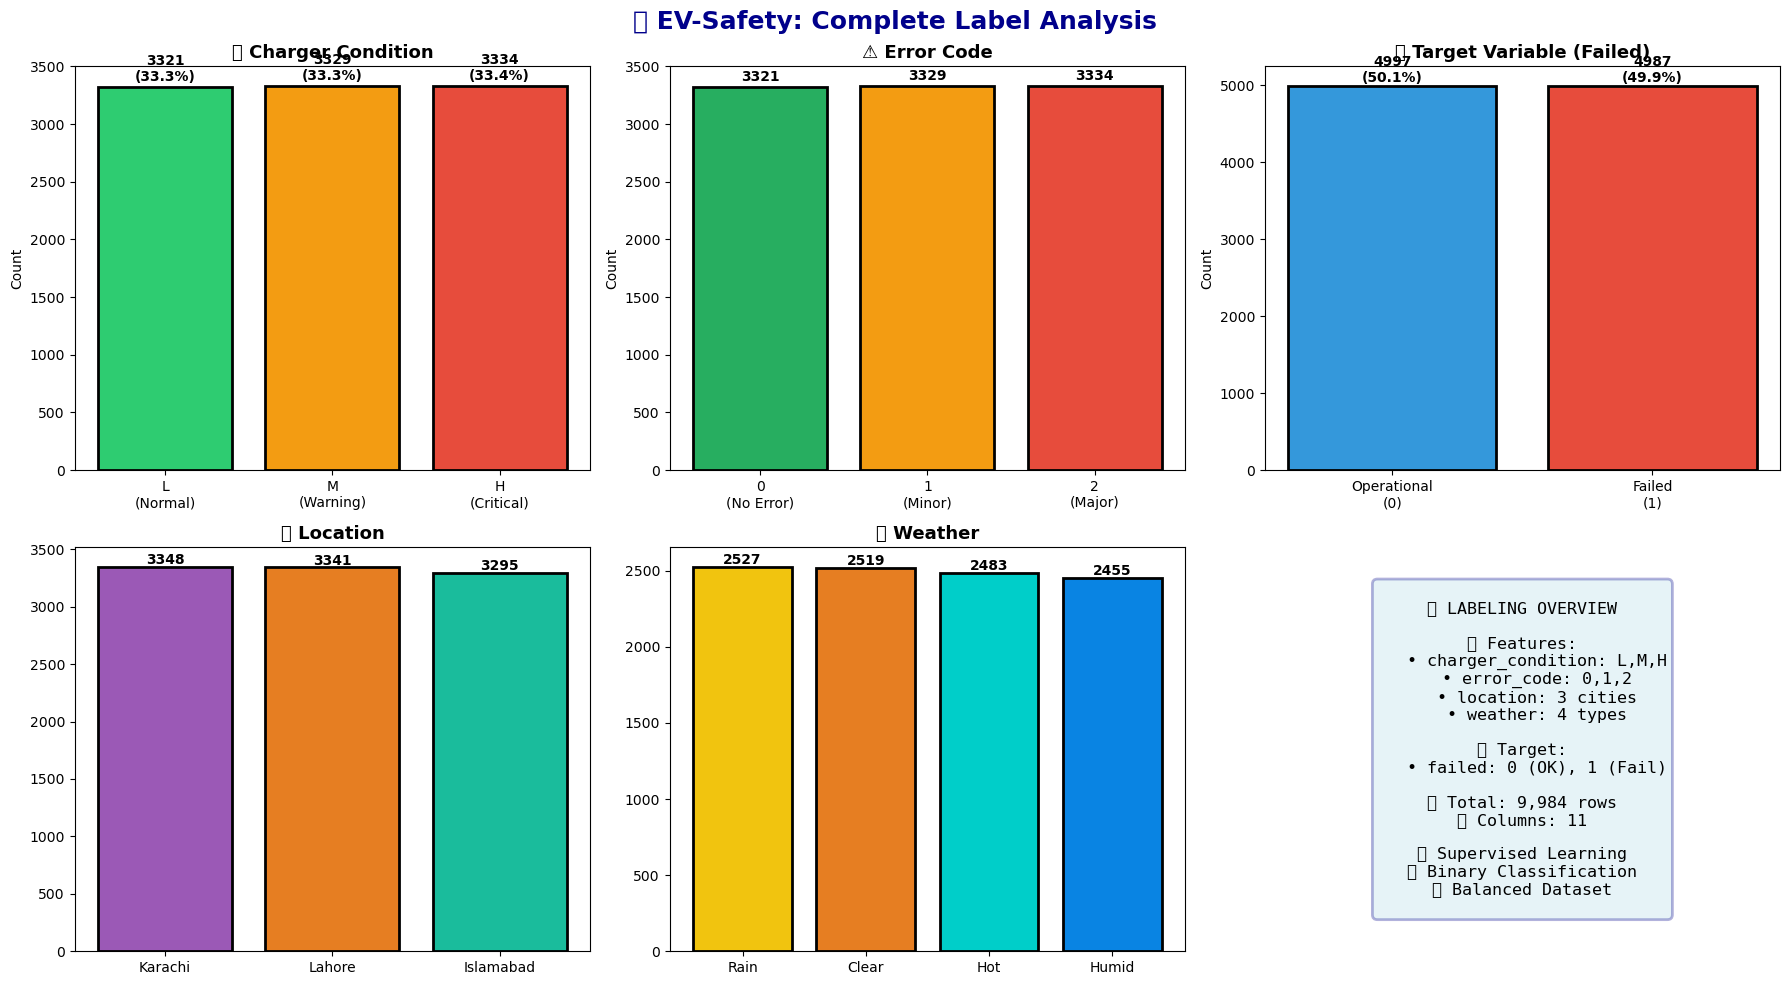

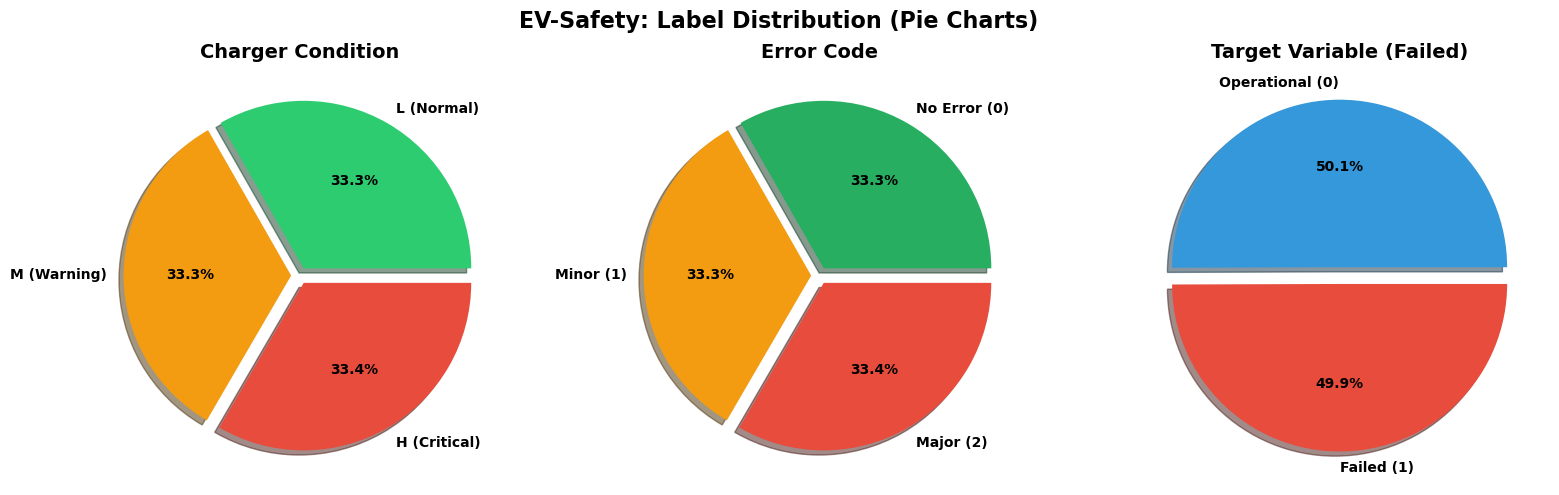

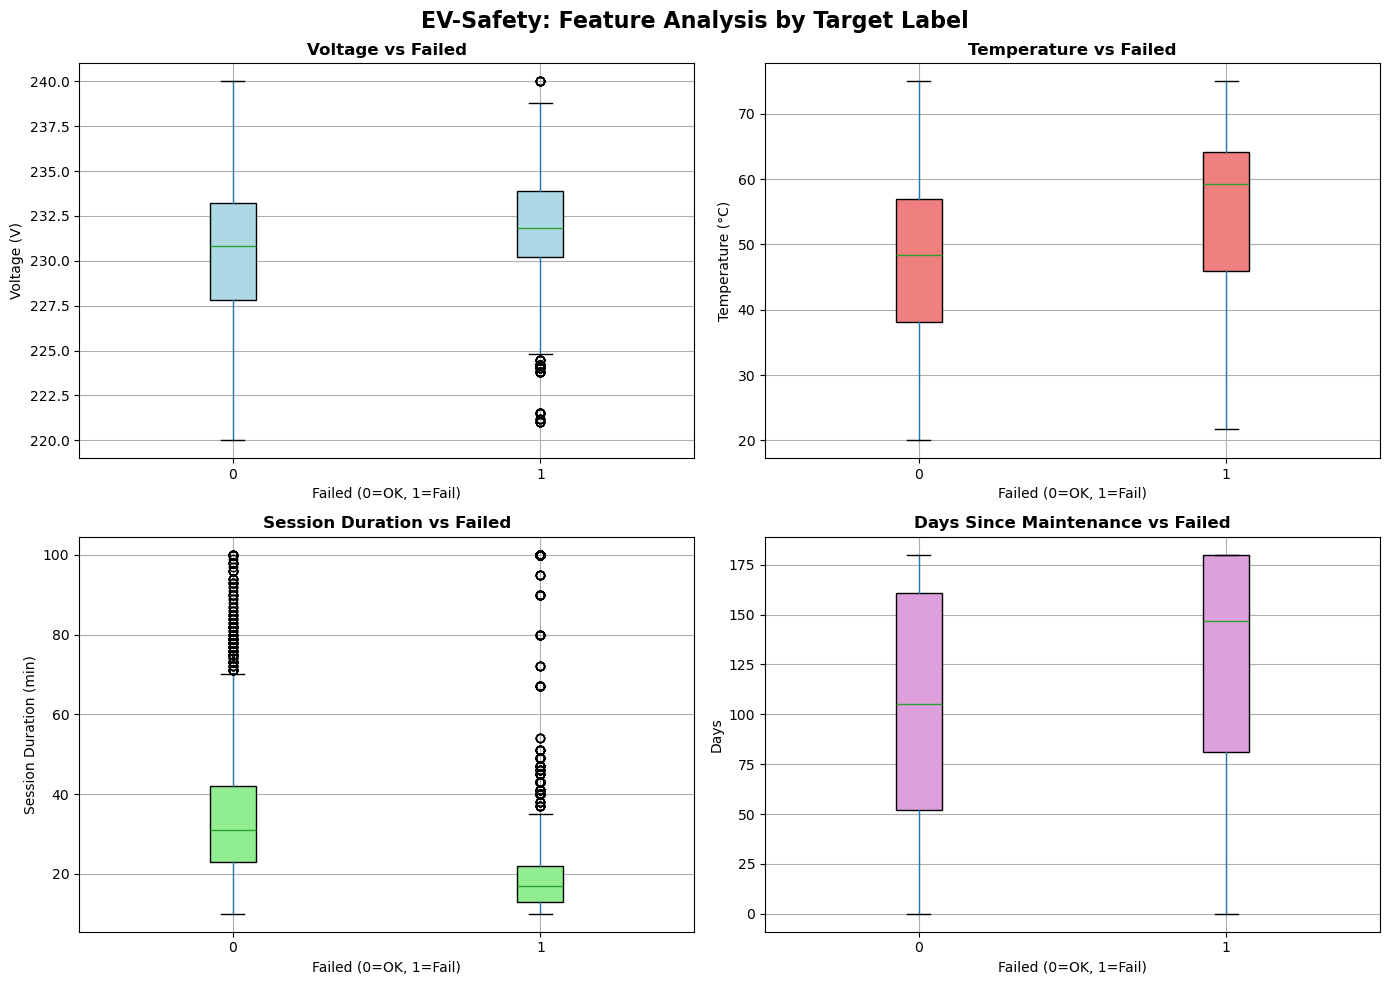

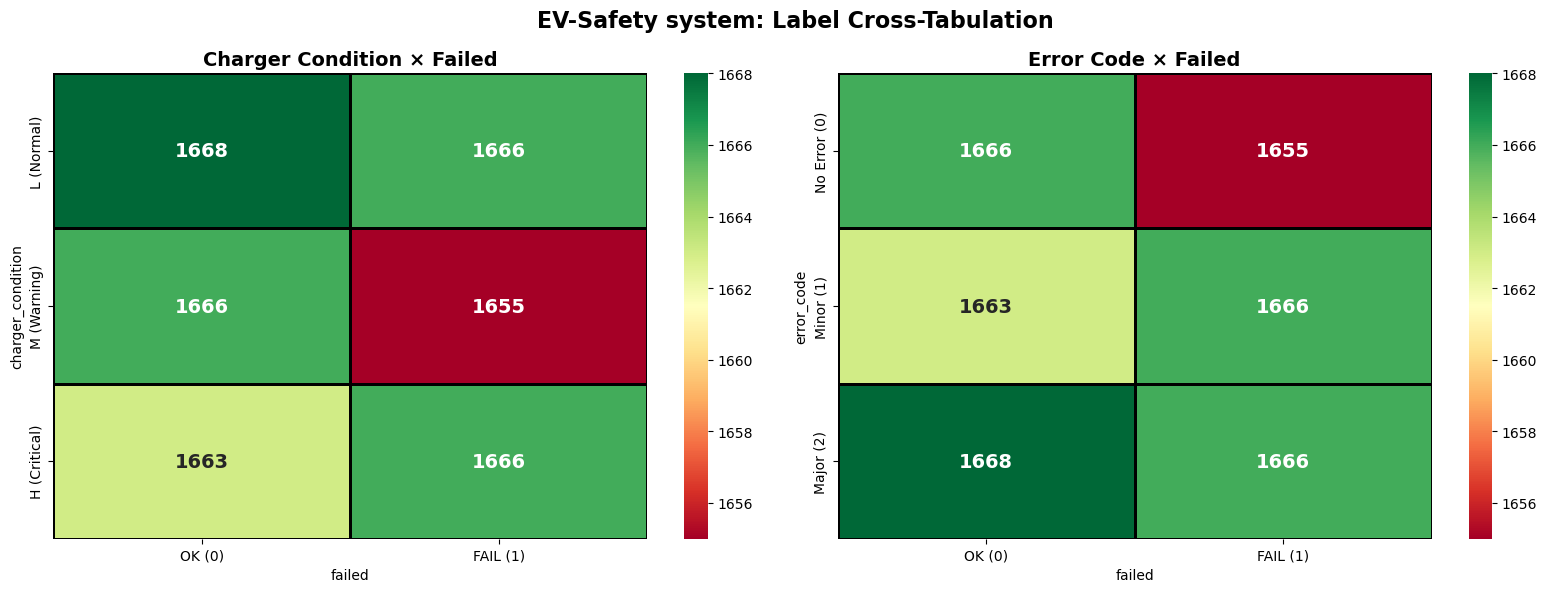


✅ LABELING COMPLETE SUMMARY

📊 DATASET OVERVIEW
─────────────────────────────────
Total Records:     9,984
Total Features:    10
Target Variable:   failed (0/1)

🔵 FEATURE LABELS:
   • charger_condition:  L, M, H (3 classes)
   • error_code:         0, 1, 2 (3 classes)
   • location:           3 cities
   • weather:            4 types

🔴 TARGET LABEL:
   • failed:  0 = Operational (4,997)
              1 = Failed (4,987)

🎯 CLASSIFICATION TYPE:
   Binary Classification (Supervised Learning)

✅ DATASET STATUS: Ready for Training!



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# LOAD DATASET
# ============================================
df = pd.read_csv('EV_Suraksha_Final.csv')

print("=" * 60)
print("🚗 EV-Safety: LABELS & VISUALIZATION")
print("=" * 60)
print(f"\n📦 Dataset Shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")

# ============================================
# 1. ALL LABELS SUMMARY
# ============================================
print("\n" + "=" * 60)
print("📊 LABELING SUMMARY")
print("=" * 60)

# Charger Condition
print("\n🔵 Charger Condition (Feature Label):")
cond = df['charger_condition'].value_counts()
for cls in ['L', 'M', 'H']:
    print(f"   {cls}: {cond.get(cls, 0):,} ({cond.get(cls, 0)/len(df)*100:.1f}%)")

# Error Code
print("\n⚠️ Error Code (Derived Feature):")
err = df['error_code'].value_counts()
for code in [0, 1, 2]:
    name = {0: 'No Error', 1: 'Minor Error', 2: 'Major Error'}
    print(f"   {code} ({name[code]}): {err.get(code, 0):,} ({err.get(code, 0)/len(df)*100:.1f}%)")

# Failed (Target)
print("\n🔴 Failed (Target Label):")
fail = df['failed'].value_counts()
print(f"   0 (Operational): {fail.get(0, 0):,} ({fail.get(0, 0)/len(df)*100:.1f}%)")
print(f"   1 (Failed):      {fail.get(1, 0):,} ({fail.get(1, 0)/len(df)*100:.1f}%)")

# Location
print("\n📍 Location (Categorical Label):")
loc = df['location'].value_counts()
for l in loc.index:
    print(f"   {l}: {loc[l]:,} ({loc[l]/len(df)*100:.1f}%)")

# Weather
print("\n🌤️ Weather (Categorical Label):")
wea = df['weather'].value_counts()
for w in wea.index:
    print(f"   {w}: {wea[w]:,} ({wea[w]/len(df)*100:.1f}%)")

# ============================================
# FIGURE 1: ALL LABELS DASHBOARD
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🚗 EV-Safety: Complete Label Analysis', fontsize=18, fontweight='bold', color='darkblue')

# Chart 1: Charger Condition
colors1 = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0, 0].bar(['L\n(Normal)', 'M\n(Warning)', 'H\n(Critical)'], 
               [cond.get('L',0), cond.get('M',0), cond.get('H',0)],
               color=colors1, edgecolor='black', linewidth=2)
axes[0, 0].set_title('🔵 Charger Condition', fontweight='bold', fontsize=13)
axes[0, 0].set_ylabel('Count')
for i, v in enumerate([cond.get('L',0), cond.get('M',0), cond.get('H',0)]):
    axes[0, 0].text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Chart 2: Error Code
colors2 = ['#27ae60', '#f39c12', '#e74c3c']
axes[0, 1].bar(['0\n(No Error)', '1\n(Minor)', '2\n(Major)'],
               [err.get(0,0), err.get(1,0), err.get(2,0)],
               color=colors2, edgecolor='black', linewidth=2)
axes[0, 1].set_title('⚠️ Error Code', fontweight='bold', fontsize=13)
axes[0, 1].set_ylabel('Count')
for i, v in enumerate([err.get(0,0), err.get(1,0), err.get(2,0)]):
    axes[0, 1].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Chart 3: Failed (Target)
axes[0, 2].bar(['Operational\n(0)', 'Failed\n(1)'], [fail.get(0,0), fail.get(1,0)],
               color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=2)
axes[0, 2].set_title('🔴 Target Variable (Failed)', fontweight='bold', fontsize=13)
axes[0, 2].set_ylabel('Count')
for i, v in enumerate([fail.get(0,0), fail.get(1,0)]):
    axes[0, 2].text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Chart 4: Location
axes[1, 0].bar(loc.index, loc.values, color=['#9b59b6', '#e67e22', '#1abc9c'], edgecolor='black', linewidth=2)
axes[1, 0].set_title('📍 Location', fontweight='bold', fontsize=13)
for i, v in enumerate(loc.values):
    axes[1, 0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Chart 5: Weather
axes[1, 1].bar(wea.index, wea.values, color=['#f1c40f', '#e67e22', '#00cec9', '#0984e3'], edgecolor='black', linewidth=2)
axes[1, 1].set_title('🌤️ Weather', fontweight='bold', fontsize=13)
for i, v in enumerate(wea.values):
    axes[1, 1].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Chart 6: Summary Box
axes[1, 2].axis('off')
summary = f"""
📊 LABELING OVERVIEW

🔵 Features:
   • charger_condition: L,M,H
   • error_code: 0,1,2
   • location: 3 cities
   • weather: 4 types

🔴 Target:
   • failed: 0 (OK), 1 (Fail)

📦 Total: {len(df):,} rows
📋 Columns: {len(df.columns)}

✅ Supervised Learning
✅ Binary Classification
✅ Balanced Dataset
"""
axes[1, 2].text(0.5, 0.5, summary, transform=axes[1, 2].transAxes,
                fontsize=12, verticalalignment='center', horizontalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3, edgecolor='darkblue', linewidth=2),
                fontfamily='monospace')

plt.tight_layout()
plt.show()

# ============================================
# FIGURE 2: PIE CHARTS - LABEL DISTRIBUTION
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie 1: Charger Condition
axes[0].pie([cond.get('L',0), cond.get('M',0), cond.get('H',0)],
            labels=['L (Normal)', 'M (Warning)', 'H (Critical)'],
            colors=['#2ecc71', '#f39c12', '#e74c3c'],
            autopct='%1.1f%%', explode=(0.05, 0.05, 0.05), shadow=True,
            textprops={'fontweight': 'bold'})
axes[0].set_title('Charger Condition', fontweight='bold', fontsize=14)

# Pie 2: Error Code
axes[1].pie([err.get(0,0), err.get(1,0), err.get(2,0)],
            labels=['No Error (0)', 'Minor (1)', 'Major (2)'],
            colors=['#27ae60', '#f39c12', '#e74c3c'],
            autopct='%1.1f%%', explode=(0.05, 0.05, 0.05), shadow=True,
            textprops={'fontweight': 'bold'})
axes[1].set_title('Error Code', fontweight='bold', fontsize=14)

# Pie 3: Failed (Target)
axes[2].pie([fail.get(0,0), fail.get(1,0)],
            labels=['Operational (0)', 'Failed (1)'],
            colors=['#3498db', '#e74c3c'],
            autopct='%1.1f%%', explode=(0.05, 0.05), shadow=True,
            textprops={'fontweight': 'bold'})
axes[2].set_title('Target Variable (Failed)', fontweight='bold', fontsize=14)

plt.suptitle('EV-Safety: Label Distribution (Pie Charts)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# FIGURE 3: TARGET vs FEATURES
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Voltage vs Failed
df.boxplot(column='voltage', by='failed', ax=axes[0, 0], patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
axes[0, 0].set_title('Voltage vs Failed', fontweight='bold')
axes[0, 0].set_xlabel('Failed (0=OK, 1=Fail)')
axes[0, 0].set_ylabel('Voltage (V)')
axes[0, 0].get_figure().suptitle('')

# Temperature vs Failed
df.boxplot(column='temperature', by='failed', ax=axes[0, 1], patch_artist=True,
           boxprops=dict(facecolor='lightcoral'))
axes[0, 1].set_title('Temperature vs Failed', fontweight='bold')
axes[0, 1].set_xlabel('Failed (0=OK, 1=Fail)')
axes[0, 1].set_ylabel('Temperature (°C)')
axes[0, 1].get_figure().suptitle('')

# Session Duration vs Failed
df.boxplot(column='session_duration', by='failed', ax=axes[1, 0], patch_artist=True,
           boxprops=dict(facecolor='lightgreen'))
axes[1, 0].set_title('Session Duration vs Failed', fontweight='bold')
axes[1, 0].set_xlabel('Failed (0=OK, 1=Fail)')
axes[1, 0].set_ylabel('Session Duration (min)')
axes[1, 0].get_figure().suptitle('')

# Days Maintenance vs Failed
df.boxplot(column='days_since_maintenance', by='failed', ax=axes[1, 1], patch_artist=True,
           boxprops=dict(facecolor='plum'))
axes[1, 1].set_title('Days Since Maintenance vs Failed', fontweight='bold')
axes[1, 1].set_xlabel('Failed (0=OK, 1=Fail)')
axes[1, 1].set_ylabel('Days')
axes[1, 1].get_figure().suptitle('')

plt.suptitle('EV-Safety: Feature Analysis by Target Label', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# FIGURE 4: HEATMAP - LABEL CORRELATIONS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: Charger Condition × Failed
ct1 = pd.crosstab(df['charger_condition'], df['failed'])
sns.heatmap(ct1, annot=True, fmt='d', cmap='RdYlGn', linewidths=2, linecolor='black',
            annot_kws={'size': 14, 'fontweight': 'bold'}, ax=axes[0],
            xticklabels=['OK (0)', 'FAIL (1)'],
            yticklabels=['L (Normal)', 'M (Warning)', 'H (Critical)'])
axes[0].set_title('Charger Condition × Failed', fontweight='bold', fontsize=14)

# Heatmap 2: Error Code × Failed
ct2 = pd.crosstab(df['error_code'], df['failed'])
sns.heatmap(ct2, annot=True, fmt='d', cmap='RdYlGn', linewidths=2, linecolor='black',
            annot_kws={'size': 14, 'fontweight': 'bold'}, ax=axes[1],
            xticklabels=['OK (0)', 'FAIL (1)'],
            yticklabels=['No Error (0)', 'Minor (1)', 'Major (2)'])
axes[1].set_title('Error Code × Failed', fontweight='bold', fontsize=14)

plt.suptitle('EV-Safety system: Label Cross-Tabulation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "=" * 60)
print("✅ LABELING COMPLETE SUMMARY")
print("=" * 60)
print(f"""
📊 DATASET OVERVIEW
─────────────────────────────────
Total Records:     {len(df):,}
Total Features:    {len(df.columns) - 1}
Target Variable:   failed (0/1)

🔵 FEATURE LABELS:
   • charger_condition:  L, M, H (3 classes)
   • error_code:         0, 1, 2 (3 classes)
   • location:           {len(loc)} cities
   • weather:            {len(wea)} types

🔴 TARGET LABEL:
   • failed:  0 = Operational ({fail.get(0,0):,})
              1 = Failed ({fail.get(1,0):,})

🎯 CLASSIFICATION TYPE:
   Binary Classification (Supervised Learning)

✅ DATASET STATUS: Ready for Training!
""")
print("=" * 60)

🚗 EV-Safety system: MULTI-MODEL + CONFUSION MATRICES

📊 COMPLETE RESULTS (WITH CONFUSION MATRIX VALUES)
        Feature Set               Model  Accuracy  AUC-ROC  TP  TN  FP  FN
         Set 1: V+T       Random Forest      88.1   0.9471 919 840 160  78
         Set 1: V+T   Gradient Boosting      77.2   0.8401 687 855 145 310
         Set 1: V+T Logistic Regression      63.9   0.6979 697 579 421 300
         Set 1: V+T                 SVM      66.2   0.7091 640 682 318 357
     Set 2: V+T+S+E       Random Forest      98.8   0.9992 997 976  24   0
     Set 2: V+T+S+E   Gradient Boosting      88.7   0.9467 882 889 111 115
     Set 2: V+T+S+E Logistic Regression      64.3   0.7157 660 625 375 337
     Set 2: V+T+S+E                 SVM      82.8   0.8925 812 841 159 185
Set 3: All Features       Random Forest      99.0   0.9999 997 980  20   0
Set 3: All Features   Gradient Boosting      90.2   0.9643 912 890 110  85
Set 3: All Features Logistic Regression      69.1   0.7457 711 669 331 

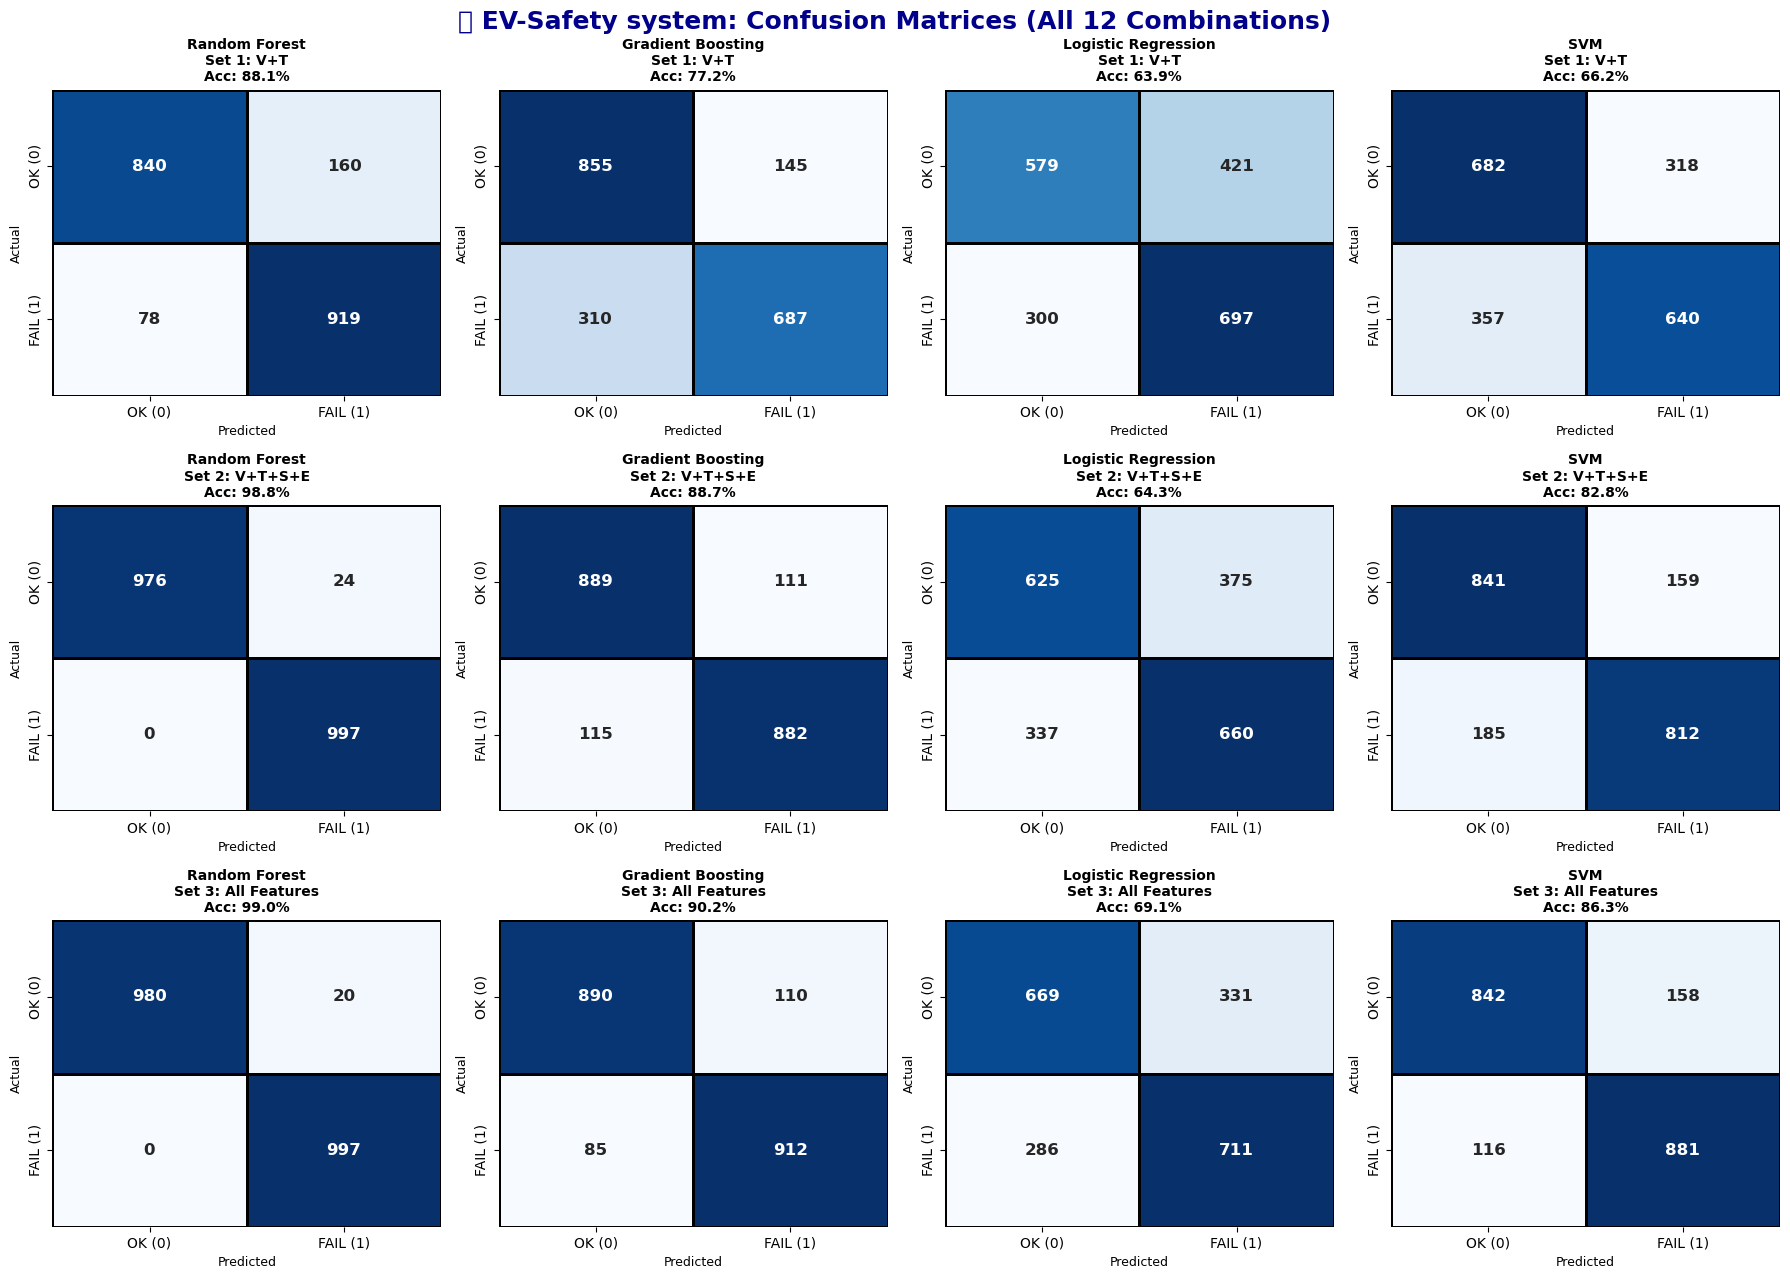

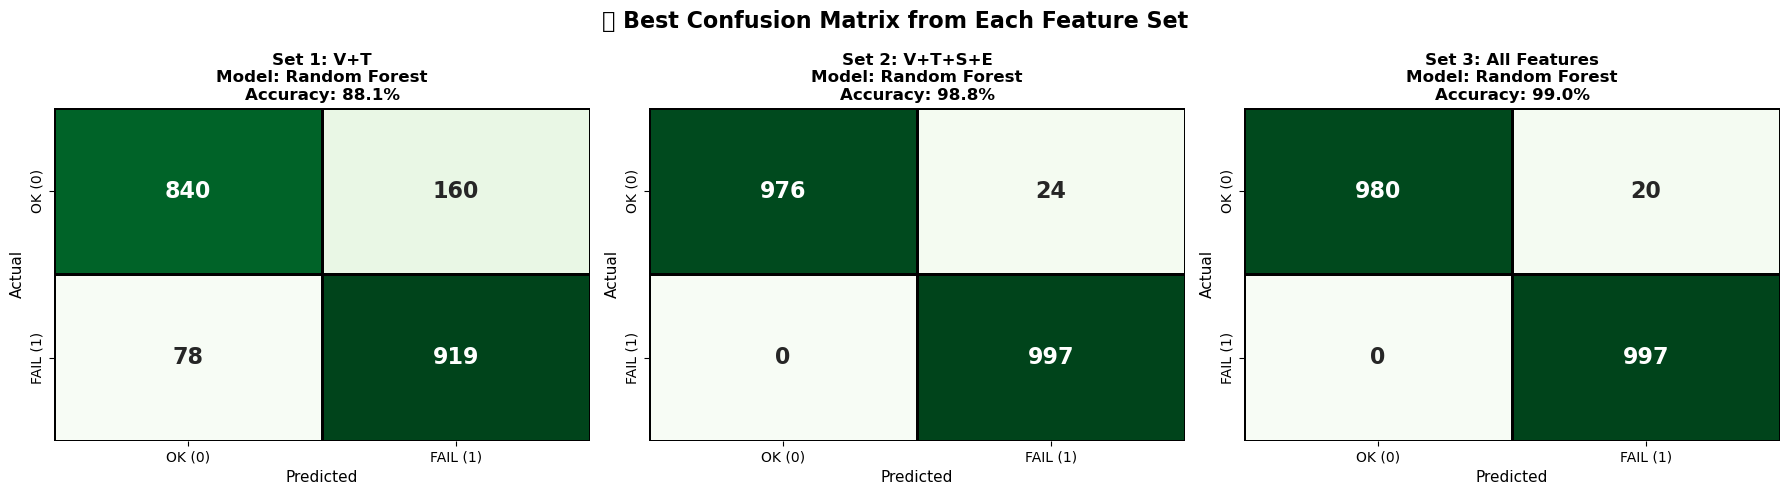

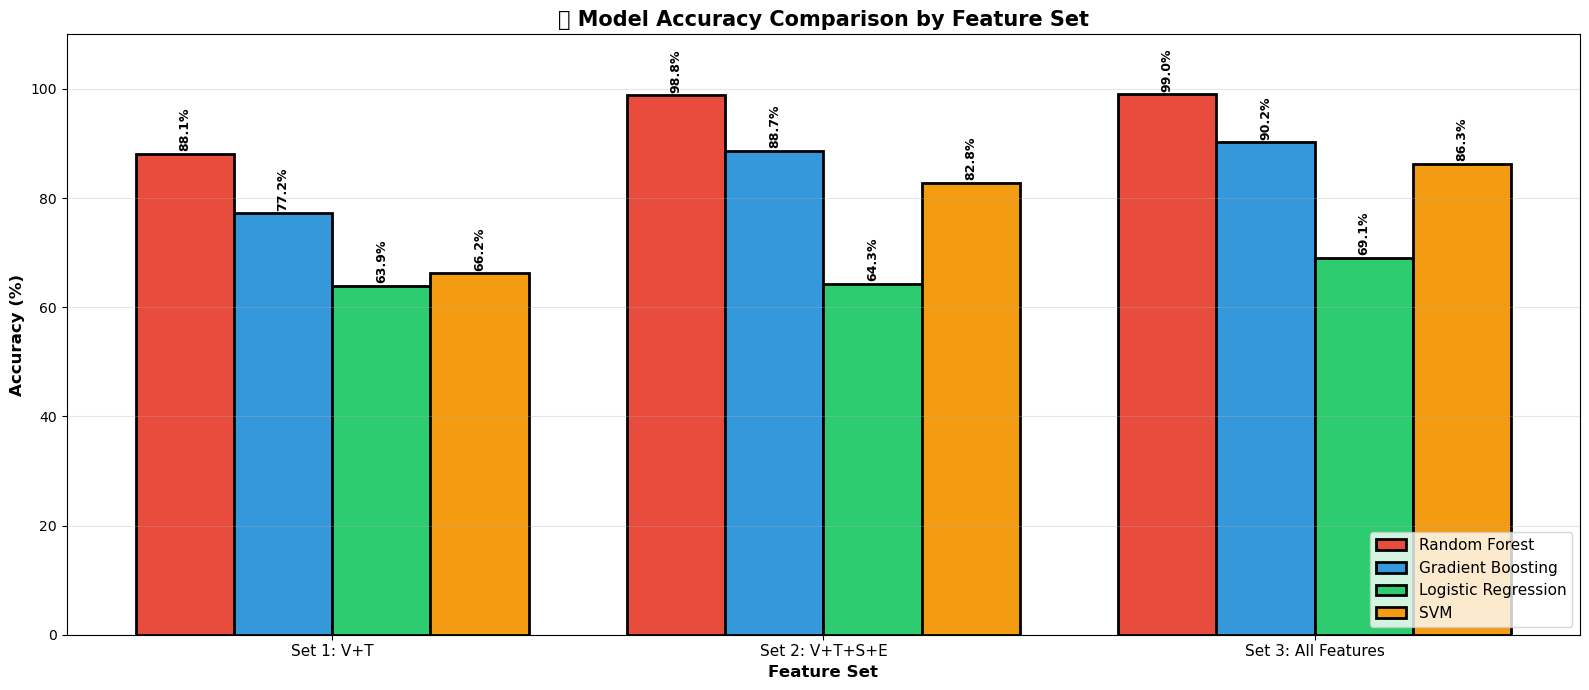

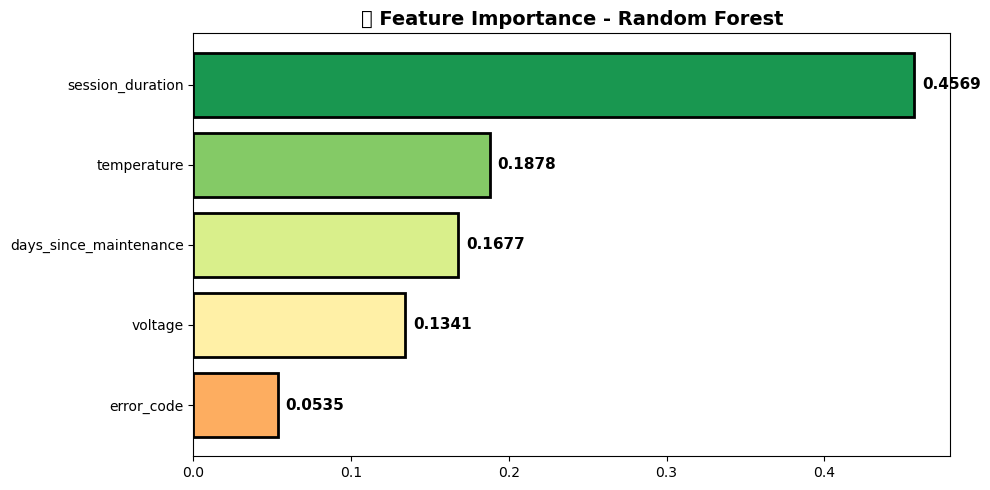


📊 CONFUSION MATRIX SUMMARY (TP, TN, FP, FN)

Set 1: V+T | Random Forest
  ✅ True Positive  (Correct Fail):  919
  ✅ True Negative  (Correct OK):    840
  ❌ False Positive (False Alarm):   160
  ❌ False Negative (Missed Fail):   78
  🎯 Accuracy: 88.1% | AUC: 0.9471

Set 1: V+T | Gradient Boosting
  ✅ True Positive  (Correct Fail):  687
  ✅ True Negative  (Correct OK):    855
  ❌ False Positive (False Alarm):   145
  ❌ False Negative (Missed Fail):   310
  🎯 Accuracy: 77.2% | AUC: 0.8401

Set 1: V+T | Logistic Regression
  ✅ True Positive  (Correct Fail):  697
  ✅ True Negative  (Correct OK):    579
  ❌ False Positive (False Alarm):   421
  ❌ False Negative (Missed Fail):   300
  🎯 Accuracy: 63.9% | AUC: 0.6979

Set 1: V+T | SVM
  ✅ True Positive  (Correct Fail):  640
  ✅ True Negative  (Correct OK):    682
  ❌ False Positive (False Alarm):   318
  ❌ False Negative (Missed Fail):   357
  🎯 Accuracy: 66.2% | AUC: 0.7091

Set 2: V+T+S+E | Random Forest
  ✅ True Positive  (Correct Fail):  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ============================================
# LOAD DATA
# ============================================
df = pd.read_csv('EV_Suraksha_Final.csv')
print("=" * 60)
print("🚗 EV-Safety system: MULTI-MODEL + CONFUSION MATRICES")
print("=" * 60)

# ============================================
# FEATURE SETS + TARGET
# ============================================
features_1 = ['voltage', 'temperature']
features_2 = ['voltage', 'temperature', 'session_duration', 'error_code']
features_3 = ['voltage', 'temperature', 'session_duration', 'error_code', 'days_since_maintenance']

all_features = [('Set 1: V+T', features_1),
                ('Set 2: V+T+S+E', features_2),
                ('Set 3: All Features', features_3)]

# ============================================
# MODELS
# ============================================
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

y = df['failed']
results = []
all_cm_data = {}  # Confusion matrices store karne ke liye

# ============================================
# TRAIN + EVALUATE ALL COMBINATIONS
# ============================================
for fset_name, features in all_features:
    X = df[features]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    for model_name, model in models.items():
        # Scale for LR & SVM
        if model_name in ['Logistic Regression', 'SVM']:
            scaler = StandardScaler()
            X_train_use = scaler.fit_transform(X_train)
            X_test_use = scaler.transform(X_test)
        else:
            X_train_use = X_train
            X_test_use = X_test
        
        # Train + Predict
        model.fit(X_train_use, y_train)
        y_pred = model.predict(X_test_use)
        y_proba = model.predict_proba(X_test_use)[:, 1]
        
        # Metrics
        acc = accuracy_score(y_test, y_pred) * 100
        auc = roc_auc_score(y_test, y_proba)
        cm = confusion_matrix(y_test, y_pred)
        
        # Store
        key = f"{fset_name} | {model_name}"
        all_cm_data[key] = {'cm': cm, 'acc': acc, 'auc': auc}
        
        results.append({
            'Feature Set': fset_name,
            'Model': model_name,
            'Accuracy': acc,
            'AUC-ROC': auc,
            'TN': cm[0][0],
            'FP': cm[0][1],
            'FN': cm[1][0],
            'TP': cm[1][1]
        })

# ============================================
# RESULTS TABLE
# ============================================
results_df = pd.DataFrame(results)
results_df['Accuracy'] = results_df['Accuracy'].round(1)
results_df['AUC-ROC'] = results_df['AUC-ROC'].round(4)

print("\n" + "=" * 80)
print("📊 COMPLETE RESULTS (WITH CONFUSION MATRIX VALUES)")
print("=" * 80)
print(results_df[['Feature Set', 'Model', 'Accuracy', 'AUC-ROC', 'TP', 'TN', 'FP', 'FN']].to_string(index=False))

# ============================================
# BEST RESULT
# ============================================
best = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\n🏆 BEST: {best['Feature Set']} | {best['Model']} | Accuracy: {best['Accuracy']}%")

# ============================================
# FIGURE 1: CONFUSION MATRICES - ALL 12
# ============================================
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.suptitle('🚗 EV-Safety system: Confusion Matrices (All 12 Combinations)', 
             fontsize=18, fontweight='bold', color='darkblue')

for idx, (key, data) in enumerate(all_cm_data.items()):
    row = idx // 4
    col = idx % 4
    
    cm = data['cm']
    acc = data['acc']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1,
                linecolor='black', annot_kws={'size': 12, 'fontweight': 'bold'},
                xticklabels=['OK (0)', 'FAIL (1)'],
                yticklabels=['OK (0)', 'FAIL (1)'],
                ax=axes[row, col], cbar=False)
    
    # Title
    parts = key.split(' | ')
    axes[row, col].set_title(f"{parts[1]}\n{parts[0]}\nAcc: {acc:.1f}%", 
                              fontsize=10, fontweight='bold')
    axes[row, col].set_xlabel('Predicted', fontsize=9)
    axes[row, col].set_ylabel('Actual', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================
# FIGURE 2: CONFUSION MATRICES - BEST FROM EACH SET
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🏆 Best Confusion Matrix from Each Feature Set', fontsize=16, fontweight='bold')

for idx, fset in enumerate(['Set 1: V+T', 'Set 2: V+T+S+E', 'Set 3: All Features']):
    best_key = None
    best_acc = 0
    
    for key in all_cm_data:
        if fset in key:
            if all_cm_data[key]['acc'] > best_acc:
                best_acc = all_cm_data[key]['acc']
                best_key = key
    
    cm = all_cm_data[best_key]['cm']
    model_name = best_key.split(' | ')[1]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', linewidths=2,
                linecolor='black', annot_kws={'size': 16, 'fontweight': 'bold'},
                xticklabels=['OK (0)', 'FAIL (1)'],
                yticklabels=['OK (0)', 'FAIL (1)'],
                ax=axes[idx], cbar=False)
    
    axes[idx].set_title(f'{fset}\nModel: {model_name}\nAccuracy: {best_acc:.1f}%', 
                        fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.show()

# ============================================
# FIGURE 3: ACCURACY COMPARISON BAR CHART
# ============================================
fig, ax = plt.subplots(figsize=(16, 7))

feature_sets = results_df['Feature Set'].unique()
model_names = list(models.keys())
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
bar_width = 0.2
x = np.arange(len(feature_sets))

for i, (model, color) in enumerate(zip(model_names, colors)):
    model_data = results_df[results_df['Model'] == model]
    accs = model_data['Accuracy'].values
    bars = ax.bar(x + i * bar_width, accs, bar_width, label=model, color=color, edgecolor='black', linewidth=2)
    
    for bar, val in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9, rotation=90)

ax.set_xlabel('Feature Set', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)
ax.set_title('🚗 Model Accuracy Comparison by Feature Set', fontweight='bold', fontsize=15)
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(feature_sets, fontsize=11)
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# FIGURE 4: FEATURE IMPORTANCE
# ============================================
X_all = df[features_3]
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_all, y)

importance = pd.DataFrame({
    'Feature': features_3,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importance)))
bars = ax.barh(importance['Feature'], importance['Importance'], color=bar_colors, edgecolor='black', linewidth=2)
ax.set_title('🌲 Feature Importance - Random Forest', fontweight='bold', fontsize=14)

for bar, val in zip(bars, importance['Importance']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# ============================================
# SUMMARY FOR EACH CONFUSION MATRIX
# ============================================
print("\n" + "=" * 70)
print("📊 CONFUSION MATRIX SUMMARY (TP, TN, FP, FN)")
print("=" * 70)
for key, data in all_cm_data.items():
    cm = data['cm']
    print(f"\n{key}")
    print(f"  ✅ True Positive  (Correct Fail):  {cm[1][1]}")
    print(f"  ✅ True Negative  (Correct OK):    {cm[0][0]}")
    print(f"  ❌ False Positive (False Alarm):   {cm[0][1]}")
    print(f"  ❌ False Negative (Missed Fail):   {cm[1][0]}")
    print(f"  🎯 Accuracy: {data['acc']:.1f}% | AUC: {data['auc']:.4f}")

print("\n" + "=" * 70)
print("✅ ANALYSIS COMPLETE!")
print("=" * 70)

🚗 EV-Safety System: Test Data Predictions

📊 Data Split:
   Training: 7987 records
   Testing:  1997 records

✅ Model Trained on 7987 records

📊 TEST DATA PREDICTIONS (First 25 Rows)
    Voltage  Temperature  Session_Duration  Error_Code Actual_Status Predicted_Status  Failure_Probability_%      Match
0     232.5         55.1                42           1          ✅ OK             ✅ OK                    0.0  ✅ Correct
1     235.5         70.8                13           2        ❌ FAIL           ❌ FAIL                  100.0  ✅ Correct
2     227.2         36.9                22           1          ✅ OK             ✅ OK                   28.0  ✅ Correct
3     232.8         60.5                18           0        ❌ FAIL           ❌ FAIL                  100.0  ✅ Correct
4     227.8         35.7                27           1          ✅ OK             ✅ OK                    1.0  ✅ Correct
5     231.8         60.5                10           1        ❌ FAIL           ❌ FAIL            

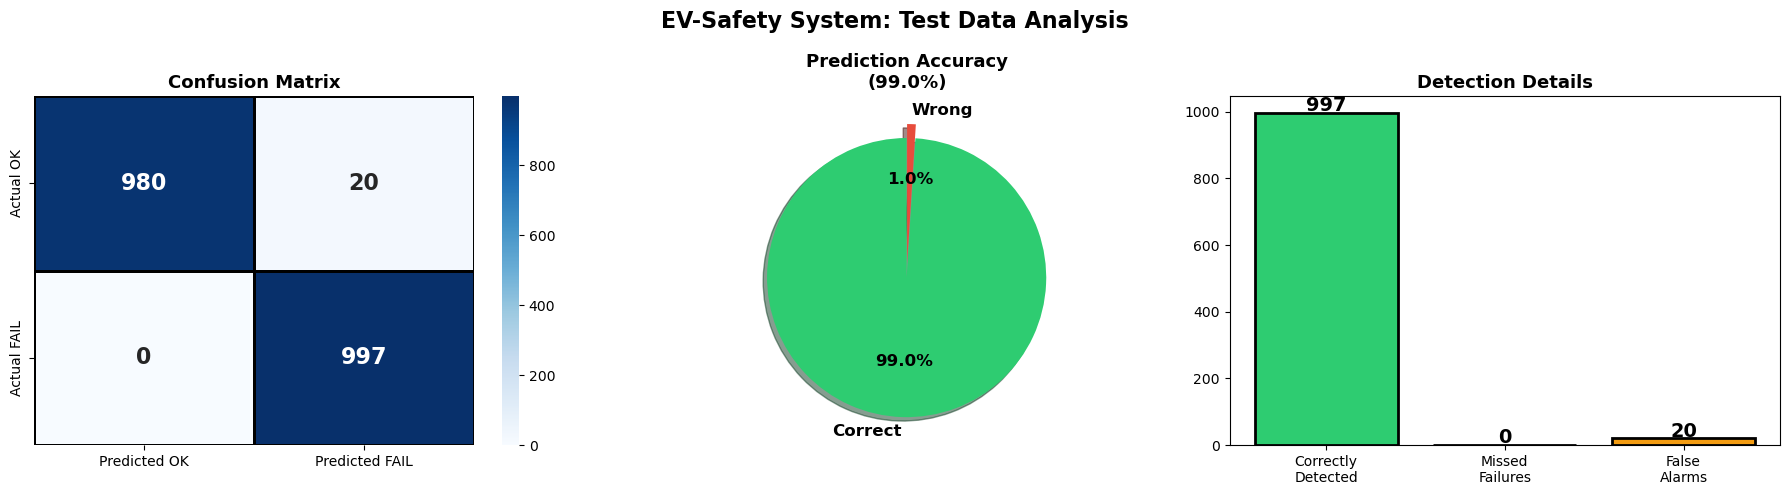


💾 Saved: EV_Safety_Test_Predictions.csv

🔮 SAMPLE PREDICTIONS (Real-World Scenarios)

📌 Normal Charger:
   Voltage=232V, Temp=40°C, Session=30min, Error=0, Days=20
   Status: ✅ OK | Risk: 1.0%
   ➡️ ✅ No action needed

📌 Warning Level:
   Voltage=218V, Temp=58°C, Session=55min, Error=1, Days=100
   Status: ✅ OK | Risk: 1.0%
   ➡️ ✅ No action needed

📌 Critical Level:
   Voltage=210V, Temp=70°C, Session=80min, Error=2, Days=180
   Status: ✅ OK | Risk: 19.0%
   ➡️ 👀 Monitor closely

📌 Severe Condition:
   Voltage=195V, Temp=78°C, Session=110min, Error=2, Days=220
   Status: ✅ OK | Risk: 23.0%
   ➡️ 👀 Monitor closely

✅ TEST DATA PREDICTION ANALYSIS COMPLETE!


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# LOAD DATA
# ============================================
df = pd.read_csv('EV_Suraksha_Final.csv')
print("=" * 60)
print("🚗 EV-Safety System: Test Data Predictions")
print("=" * 60)

# ============================================
# USE THE BEST FEATURE SET (Set 3: All Features)
# ============================================
features = ['voltage', 'temperature', 'session_duration', 'error_code', 'days_since_maintenance']
X = df[features]
y = df['failed']

# ============================================
# 80-20 TRAIN-TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Data Split:")
print(f"   Training: {len(X_train)} records")
print(f"   Testing:  {len(X_test)} records")

# ============================================
# TRAIN BEST MODEL (Random Forest)
# ============================================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(f"\n✅ Model Trained on {len(X_train)} records")

# ============================================
# PREDICT ON TEST DATA
# ============================================
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# ============================================
# CREATE RESULTS DATAFRAME
# ============================================
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Failure_Probability_%': (y_proba * 100).round(1),
    'Voltage': X_test['voltage'].values.round(1),
    'Temperature': X_test['temperature'].values.round(1),
    'Session_Duration': X_test['session_duration'].values,
    'Error_Code': X_test['error_code'].values,
    'Days_Maintenance': X_test['days_since_maintenance'].values
})

# Add labels
results['Actual_Status'] = results['Actual'].map({0: '✅ OK', 1: '❌ FAIL'})
results['Predicted_Status'] = results['Predicted'].map({0: '✅ OK', 1: '❌ FAIL'})
results['Match'] = (results['Actual'] == results['Predicted']).map({True: '✅ Correct', False: '❌ Wrong'})

# ============================================
# DISPLAY RESULTS
# ============================================
print("\n" + "=" * 80)
print("📊 TEST DATA PREDICTIONS (First 25 Rows)")
print("=" * 80)

display_cols = ['Voltage', 'Temperature', 'Session_Duration', 'Error_Code',
                'Actual_Status', 'Predicted_Status', 'Failure_Probability_%', 'Match']
print(results[display_cols].head(25).to_string(index=True))

# ============================================
# SUMMARY STATISTICS
# ============================================
total = len(results)
correct = (results['Actual'] == results['Predicted']).sum()
wrong = total - correct

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

print("\n" + "=" * 60)
print("📊 TEST DATA PERFORMANCE SUMMARY")
print("=" * 60)
print(f"""
   Total Test Records:  {total}
   ✅ Correct:          {correct} ({correct/total*100:.1f}%)
   ❌ Wrong:            {wrong} ({wrong/total*100:.1f}%)

   Confusion Matrix:
   ┌──────────────────┬──────────────┬──────────────┐
   │                  │ Predicted OK │ Predicted FAIL│
   ├──────────────────┼──────────────┼──────────────┤
   │ Actual OK        │     {tn}      │     {fp}       │
   │ Actual FAIL      │     {fn}       │     {tp}      │
   └──────────────────┴──────────────┴──────────────┘

   ✅ True Positive  (FAIL → FAIL):  {tp}   (Correctly caught)
   ✅ True Negative  (OK → OK):      {tn}   (Correctly passed)
   ❌ False Positive (OK → FAIL):    {fp}    (False alarm)
   ❌ False Negative (FAIL → OK):    {fn}     (Missed failure!)
""")

# ============================================
# WRONG PREDICTIONS
# ============================================
wrong_cases = results[results['Actual'] != results['Predicted']]

if len(wrong_cases) > 0:
    print("=" * 60)
    print(f"❌ WRONG PREDICTIONS ({len(wrong_cases)} cases)")
    print("=" * 60)
    print(wrong_cases[['Voltage', 'Temperature', 'Error_Code', 
                       'Actual_Status', 'Predicted_Status', 'Failure_Probability_%']].to_string())
else:
    print("\n🎉 PERFECT! No wrong predictions!")

# ============================================
# SHOW FAIL CASES (Most Important)
# ============================================
actual_fails = results[results['Actual'] == 1]
print(f"\n" + "=" * 60)
print(f"🔴 ACTUAL FAILURE CASES ({len(actual_fails)} total)")
print("=" * 60)
print(f"   Correctly Detected: {len(actual_fails[actual_fails['Predicted']==1])}")
print(f"   Missed (FN):        {len(actual_fails[actual_fails['Predicted']==0])}")
print(f"   Detection Rate:      {len(actual_fails[actual_fails['Predicted']==1])/len(actual_fails)*100:.1f}%")

# ============================================
# SHOW OK CASES
# ============================================
actual_ok = results[results['Actual'] == 0]
print(f"\n" + "=" * 60)
print(f"🟢 ACTUAL OK CASES ({len(actual_ok)} total)")
print("=" * 60)
print(f"   Correctly Passed:   {len(actual_ok[actual_ok['Predicted']==0])}")
print(f"   False Alarm (FP):   {len(actual_ok[actual_ok['Predicted']==1])}")
print(f"   Pass Rate:           {len(actual_ok[actual_ok['Predicted']==0])/len(actual_ok)*100:.1f}%")

# ============================================
# VISUALIZATION
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=2,
            linecolor='black', annot_kws={'size': 16, 'fontweight': 'bold'},
            xticklabels=['Predicted OK', 'Predicted FAIL'],
            yticklabels=['Actual OK', 'Actual FAIL'], ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)

# 2. Accuracy Pie
axes[1].pie([correct, wrong], labels=['Correct', 'Wrong'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, explode=(0.05, 0.05), shadow=True,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title(f'Prediction Accuracy\n({correct/total*100:.1f}%)', fontweight='bold', fontsize=13)

# 3. Failure Detection Rate
axes[2].bar(['Correctly\nDetected', 'Missed\nFailures', 'False\nAlarms'],
            [tp, fn, fp],
            color=['#2ecc71', '#e74c3c', '#f39c12'], edgecolor='black', linewidth=2)
axes[2].set_title('Detection Details', fontweight='bold', fontsize=13)
for i, v in enumerate([tp, fn, fp]):
    axes[2].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=14)

plt.suptitle('EV-Safety System: Test Data Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# SAVE RESULTS
# ============================================
results.to_csv('EV_Safety_Test_Predictions.csv', index=False)
print("\n💾 Saved: EV_Safety_Test_Predictions.csv")

# ============================================
# PREDICTION FUNCTION (For Future Use)
# ============================================
def predict_charger(voltage, temperature, session_duration, error_code, days_maintenance):
    """Single charger prediction"""
    input_df = pd.DataFrame([[voltage, temperature, session_duration, error_code, days_maintenance]],
                            columns=features)
    pred = model.predict(input_df)[0]
    prob = model.predict_proba(input_df)[0][1] * 100
    
    status = '❌ FAIL' if pred == 1 else '✅ OK'
    
    if prob > 70:
        recommendation = '🚨 IMMEDIATE MAINTENANCE REQUIRED!'
    elif prob > 40:
        recommendation = '⚠️ Schedule inspection within 3 days'
    elif prob > 15:
        recommendation = '👀 Monitor closely'
    else:
        recommendation = '✅ No action needed'
    
    return {
        'Status': status,
        'Failure_Probability': f'{prob:.1f}%',
        'Recommendation': recommendation
    }

print("\n" + "=" * 60)
print("🔮 SAMPLE PREDICTIONS (Real-World Scenarios)")
print("=" * 60)

test_scenarios = [
    ("Normal Charger", 232, 40, 30, 0, 20),
    ("Warning Level",  218, 58, 55, 1, 100),
    ("Critical Level", 210, 70, 80, 2, 180),
    ("Severe Condition", 195, 78, 110, 2, 220),
]

for name, v, t, s, e, d in test_scenarios:
    result = predict_charger(v, t, s, e, d)
    print(f"\n📌 {name}:")
    print(f"   Voltage={v}V, Temp={t}°C, Session={s}min, Error={e}, Days={d}")
    print(f"   Status: {result['Status']} | Risk: {result['Failure_Probability']}")
    print(f"   ➡️ {result['Recommendation']}")

print("\n" + "=" * 60)
print("✅ TEST DATA PREDICTION ANALYSIS COMPLETE!")
print("=" * 60)